In [1]:
# Cell 1: Load data, GA results, and run RF tuning for
#         Baseline + GA top-5 USING THE OLD TUNING FUNCTION

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from IPython.display import display

from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import recall_score

from sklearn.ensemble import RandomForestClassifier
import shap
# ------------------------------------
# 1) Load train / test data
# ------------------------------------

X_train = pd.read_csv("../nz/Xtr_nz.csv")
X_test  = pd.read_csv("../nz/Xte_nz.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

y_np = y_train.to_numpy().ravel()
y_te = y_test.to_numpy().ravel()

# ------------------------------------
# 2) Load GA results (ga_best.npz)
# ------------------------------------
ga_npz = np.load("../data/ga_svm_nonzero_nopenalty.npz", allow_pickle=True)
print("\n[INFO] npz keys:", ga_npz.files)

top_scores = np.asarray(ga_npz["top_scores"], dtype=float)

# Build top_cols_all from npz (handle both 'top_masks' and 'top_cols')
if "top_masks" in ga_npz.files:
    raw_masks = list(ga_npz["top_masks"])  # list of boolean arrays
    top_cols_all = [
        np.flatnonzero(np.asarray(m, dtype=bool)).astype(int)
        for m in raw_masks
    ]
else:
    raw_cols = list(ga_npz["top_cols"])    # list of index arrays
    top_cols_all = [np.asarray(c, dtype=int) for c in raw_cols]

n_feat_total = X_train.shape[1]
print(f"[INFO] Loaded {len(top_cols_all)} GA feature sets.")

# ------------------------------------
# 3) Define PARAM_DIST and old tuning settings
#    (EXACTLY as in your previous test code)
# ------------------------------------
PARAM_DIST = {
    "n_estimators": randint(100, 650),
    "max_depth": [None, 8, 12],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 8),
    "bootstrap": [True],
    "max_samples": [None, 0.6, 0.8, 1.0],
    "class_weight": [None, "balanced"],
    "criterion": ["gini", "entropy"],
}

STAGE1_N_ITER = globals().get("STAGE1_N_ITER", 80)  # keep 80 if defined, same as before
RANDOM_STATE  = 42

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)

def tune_rf_for_features(feature_idx, label):
    """
    RF hyperparameter tuning on a given feature subset using the EXACT same
    RandomizedSearchCV settings as before (so results are comparable).
    """
    X_sub = X_train.iloc[:, feature_idx].to_numpy()

    rs = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=2042, n_jobs=-1),
        param_distributions=PARAM_DIST,
        n_iter=STAGE1_N_ITER,
        scoring="roc_auc",
        cv=cv5,
        n_jobs=-1,
        random_state=2042,
        verbose=0
    )
    rs.fit(X_sub, y_np)

    best_params = dict(rs.best_params_)
    # Clean up for direct RF instantiation
    best_params.pop("random_state", None)
    best_params.pop("n_jobs", None)
    if best_params.get("bootstrap") is False:
        best_params.pop("max_samples", None)

    print(f"[CV] {label} best AUC = {rs.best_score_:.4f}")
    print(f"[CV] {label} best params = {best_params}")
    return best_params, float(rs.best_score_)

# ------------------------------------
# 4) Build feature_sets: Baseline + GA top-5 (by GA score)
# ------------------------------------
N_TOP_GA = 5

# sort GA solutions by GA score (descending)
sorted_idx = np.argsort(top_scores)[::-1]
top_idx    = sorted_idx[:N_TOP_GA]

feature_sets = []

# (0) Baseline: all 84 features
all_cols = np.arange(n_feat_total, dtype=int)
feature_sets.append({
    "name": "Baseline (ALL wrapper)",
    "cols": all_cols,
})

# (1) GA top-5 feature subsets
for rank, idx in enumerate(top_idx, 1):
    cols = np.asarray(top_cols_all[idx], dtype=int)
    feature_sets.append({
        "name": f"GA-{rank} (idx={idx})",
        "cols": cols,
        "ga_score": float(top_scores[idx]),
    })

print("\n[INFO] Feature sets to tune (Baseline + GA top-5):")
for fs in feature_sets:
    print(f"  {fs['name']}: d={len(fs['cols'])}")

# ------------------------------------
# 5) Run tuning for each feature set USING THE SAME FUNCTION
# ------------------------------------
for fs in feature_sets:
    params, cv_auc = tune_rf_for_features(fs["cols"], fs["name"])
    fs["best_params"] = params
    fs["cv_auc"]      = cv_auc


c:\Users\junse\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


X_train: (82, 32)
X_test : (36, 32)
y_train: (82,)
y_test : (36,)

[INFO] npz keys: ['run_ids', 'top_scores', 'top_masks', 'top_cols']
[INFO] Loaded 5 GA feature sets.

[INFO] Feature sets to tune (Baseline + GA top-5):
  Baseline (ALL wrapper): d=32
  GA-1 (idx=0): d=21
  GA-2 (idx=1): d=23
  GA-3 (idx=2): d=16
  GA-4 (idx=3): d=20
  GA-5 (idx=4): d=19
[CV] Baseline (ALL wrapper) best AUC = 0.8733
[CV] Baseline (ALL wrapper) best params = {'bootstrap': True, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 8, 'max_features': 0.3, 'max_samples': 0.6, 'min_samples_leaf': 1, 'min_samples_split': 15, 'n_estimators': 135}
[CV] GA-1 (idx=0) best AUC = 0.9061
[CV] GA-1 (idx=0) best params = {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'max_samples': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 100}
[CV] GA-2 (idx=1) best AUC = 0.8700
[CV] GA-2 (idx=1) best params = {'bootstrap': True, 'class_weig

[Train CV ROC] Baseline (ALL wrapper): AUC 0.8733 ± 0.0884
[Train CV ROC] GA-1 (idx=0): AUC 0.9061 ± 0.0340
[Train CV ROC] GA-2 (idx=1): AUC 0.8700 ± 0.0902
[Train CV ROC] GA-3 (idx=2): AUC 0.8742 ± 0.0635
[Train CV ROC] GA-4 (idx=3): AUC 0.8642 ± 0.0990
[Train CV ROC] GA-5 (idx=4): AUC 0.8485 ± 0.1027


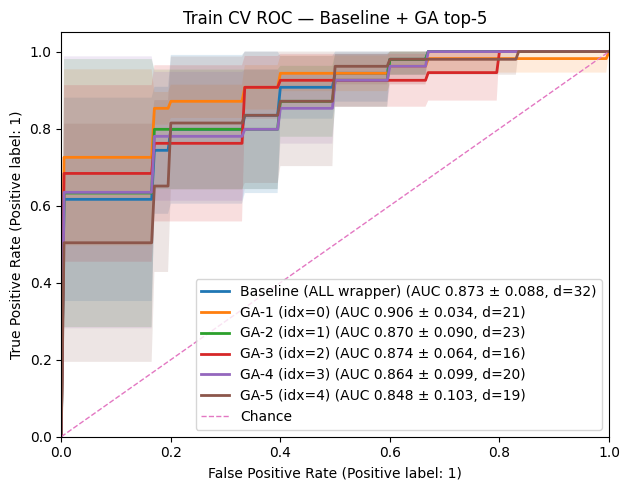

In [2]:
# Cell 2: Train CV ROC for Baseline + GA top-5
#         (NO NEW TUNING; use fs["best_params"] from Cell 1)

FPR_GRID = np.linspace(0.0, 1.0, 201)

def cv_roc_with_fixed_params(X, y, params, label, cv):
    """
    Given fixed RF params, compute mean ± std ROC curves over the given CV object.
    """
    tprs = []
    aucs = []

    for tr_idx, va_idx in cv.split(X, y):
        clf = RandomForestClassifier(
            random_state=2042,
            n_jobs=-1,
            **params
        )
        clf.fit(X[tr_idx], y[tr_idx])
        prob = clf.predict_proba(X[va_idx])[:, 1]

        fpr, tpr, _ = roc_curve(y[va_idx], prob)
        auc_fold = roc_auc_score(y[va_idx], prob)
        aucs.append(auc_fold)

        tpr_i = np.interp(FPR_GRID, fpr, tpr, left=0.0, right=1.0)
        tpr_i[0]  = 0.0
        tpr_i[-1] = 1.0
        tprs.append(tpr_i)

    tprs     = np.vstack(tprs)
    mean_tpr = tprs.mean(axis=0)
    std_tpr  = tprs.std(axis=0)
    auc_mean = float(np.mean(aucs))
    auc_std  = float(np.std(aucs))

    print(f"[Train CV ROC] {label}: AUC {auc_mean:.4f} ± {auc_std:.4f}")
    return mean_tpr, std_tpr, auc_mean, auc_std

plt.figure(figsize=(6.4, 5.0))

for fs in feature_sets:
    cols   = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])

    X_sub = X_train.iloc[:, cols].to_numpy()

    mean_tpr, std_tpr, auc_mean, auc_std = cv_roc_with_fixed_params(
        X_sub, y_np, params, fs["name"], cv5
    )

    fs["cv_auc_mean"] = auc_mean
    fs["cv_auc_std"]  = auc_std

    label = f"{fs['name']} (AUC {auc_mean:.3f} ± {auc_std:.3f}, d={len(cols)})"
    plt.plot(FPR_GRID, mean_tpr, lw=2, label=label)
    plt.fill_between(
        FPR_GRID,
        np.maximum(mean_tpr - std_tpr, 0.0),
        np.minimum(mean_tpr + std_tpr, 1.0),
        alpha=0.15,
    )

plt.plot([0, 1], [0, 1], "--", lw=1, label="Chance")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("Train CV ROC — Baseline + GA top-5")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [3]:
# ------------------------------------------------
# 1) Collect only GA-based feature sets (exclude Baseline)
# ------------------------------------------------
ga_feature_sets = [fs for fs in feature_sets if fs["name"].startswith("GA-")]

if len(ga_feature_sets) == 0:
    raise ValueError("No GA feature sets found. Make sure feature_sets contains entries named 'GA-1', 'GA-2', ...")

# Each GA subset already has:
#   - fs["cv_auc_mean"]: mean AUC over CV folds (from Cell 2)
#   - fs["cv_auc_std"] : std  AUC over CV folds (from Cell 2)
# We now summarize:
#   (1) per-subset CV AUC statistics in a table
#   (2) across-subset AUC stability: how much these per-subset means vary
#       -> treat each GA run's cv_auc_mean as one observation
#          and compute mean / std across runs.

subset_names = [fs["name"] for fs in ga_feature_sets]
subset_sizes = [len(fs["cols"]) for fs in ga_feature_sets]
ga_auc_means = np.array([fs["cv_auc_mean"] for fs in ga_feature_sets], dtype=float)
ga_auc_stds  = np.array([fs["cv_auc_std"]  for fs in ga_feature_sets], dtype=float)

# --------------------------------------------
# Table 1: per-GA-subset CV AUC summary
# --------------------------------------------
auc_table = pd.DataFrame({
    "subset": subset_names,
    "n_features": subset_sizes,
    "cv_auc_mean_over_folds": ga_auc_means,
    "cv_auc_std_over_folds": ga_auc_stds,
})
auc_table = auc_table.sort_values("subset").reset_index(drop=True)

# Across-subset AUC stability:
#   - ga_auc_means: length = n_GA_runs (e.g., 5)
#   - mean: average AUC across GA runs
#   - std : how much the *average* AUC changes between GA runs
auc_across_mean = float(ga_auc_means.mean())
auc_across_std  = float(ga_auc_means.std(ddof=1))  # sample std across GA subsets

auc_stability_summary = pd.DataFrame({
    "metric": ["across_subsets_mean_AUC", "across_subsets_std_AUC"],
    "value":  [auc_across_mean,            auc_across_std]
})

# --------------------------------------------
# 2) Jaccard similarity between GA subsets
# --------------------------------------------
def jaccard_similarity(indices_a, indices_b):
    """
    Compute Jaccard similarity between two index sets:
      J(A,B) = |A ∩ B| / |A ∪ B|
    """
    set_a = set(indices_a)
    set_b = set(indices_b)
    union = set_a | set_b
    if not union:
        return 0.0
    inter = set_a & set_b
    return len(inter) / len(union)

n_ga   = len(ga_feature_sets)
labels = [fs["name"] for fs in ga_feature_sets]

jacc_matrix = np.zeros((n_ga, n_ga), dtype=float)

# Full Jaccard matrix (symmetric, diagonal = 1)
for i in range(n_ga):
    for j in range(n_ga):
        jacc_matrix[i, j] = jaccard_similarity(
            ga_feature_sets[i]["cols"],
            ga_feature_sets[j]["cols"]
        )

# DataFrame for a clean matrix view
jacc_df = pd.DataFrame(jacc_matrix, index=labels, columns=labels)

# Upper-triangular values (i < j) for summary mean ± std
upper_vals = [
    jacc_matrix[i, j]
    for i in range(n_ga)
    for j in range(i + 1, n_ga)
]

jacc_mean = float(np.mean(upper_vals)) if upper_vals else 0.0
jacc_std  = float(np.std(upper_vals, ddof=1)) if len(upper_vals) > 1 else 0.0

jacc_summary = pd.DataFrame({
    "metric": ["mean_Jaccard_over_pairs", "std_Jaccard_over_pairs"],
    "value":  [jacc_mean,                  jacc_std]
})


# --------------------------------------------
# 3) Sensitivity comparison: mean recall at 0.5
# --------------------------------------------
def cv_sensitivity_at_threshold(X, y, params, cv, threshold=0.5):
    """
    Compute mean ± std sensitivity (recall for positive class)
    across CV folds, at a fixed probability threshold.
    """
    recalls = []

    for tr_idx, va_idx in cv.split(X, y):
        clf = RandomForestClassifier(
            random_state=2042,
            n_jobs=-1,
            **params
        )
        clf.fit(X[tr_idx], y[tr_idx])
        prob = clf.predict_proba(X[va_idx])[:, 1]

        y_pred = (prob >= threshold).astype(int)
        rec = recall_score(y[va_idx], y_pred, pos_label=1)
        recalls.append(rec)

    recalls = np.array(recalls, dtype=float)
    return float(recalls.mean()), float(recalls.std(ddof=1))

sens_rows = []
for fs in ga_feature_sets:
    cols   = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])
    X_sub  = X_train.iloc[:, cols].to_numpy()
    y_sub  = y_np  # same labels as before

    sens_mean, sens_std = cv_sensitivity_at_threshold(
        X_sub, y_sub, params, cv5, threshold=0.5
    )

    sens_rows.append({
        "subset": fs["name"],
        "n_features": len(cols),
        "cv_auc_mean_over_folds": fs["cv_auc_mean"],
        "cv_auc_std_over_folds":  fs["cv_auc_std"],
        "sensitivity_mean_at_0.5": sens_mean,
        "sensitivity_std_at_0.5":  sens_std,
    })

sens_table = pd.DataFrame(sens_rows).sort_values("subset").reset_index(drop=True)


# --------------------------------------------
# 4) Display all tables nicely
# --------------------------------------------
# (You can remove .round(...) if you want full precision.)
display(auc_table.round(3))             # Table: per-GA-subset AUC
display(auc_stability_summary.round(4)) # Table: across-subset AUC stability
display(jacc_df.round(3))               # Table: Jaccard matrix
display(jacc_summary.round(4))          # Table: Jaccard mean/std
display(sens_table.round(3))            # Table: AUC + sensitivity per GA subset


,subset,n_features,cv_auc_mean_over_folds,cv_auc_std_over_folds
0,GA-1 (idx=0),21,0.906,0.034
1,GA-2 (idx=1),23,0.870,0.090
2,GA-3 (idx=2),16,0.874,0.064
3,GA-4 (idx=3),20,0.864,0.099
4,GA-5 (idx=4),19,0.848,0.103


,metric,value
0,across_subsets_mean_AUC,0.8726
1,across_subsets_std_AUC,0.0211


,GA-1 (idx=0),GA-2 (idx=1),GA-3 (idx=2),GA-4 (idx=3),GA-5 (idx=4)
GA-1 (idx=0),1.000,0.517,0.542,0.519,0.538
GA-2 (idx=1),0.517,1.000,0.393,0.654,0.615
GA-3 (idx=2),0.542,0.393,1.000,0.565,0.522
GA-4 (idx=3),0.519,0.654,0.565,1.000,0.696
GA-5 (idx=4),0.538,0.615,0.522,0.696,1.000


,metric,value
0,mean_Jaccard_over_pairs,0.5561
1,std_Jaccard_over_pairs,0.0843


,subset,n_features,cv_auc_mean_over_folds,cv_auc_std_over_folds,sensitivity_mean_at_0.5,sensitivity_std_at_0.5
0,GA-1 (idx=0),21,0.906,0.034,0.907,0.064
1,GA-2 (idx=1),23,0.870,0.090,0.964,0.050
2,GA-3 (idx=2),16,0.874,0.064,0.964,0.050
3,GA-4 (idx=3),20,0.864,0.099,1.000,0.000
4,GA-5 (idx=4),19,0.848,0.103,1.000,0.000


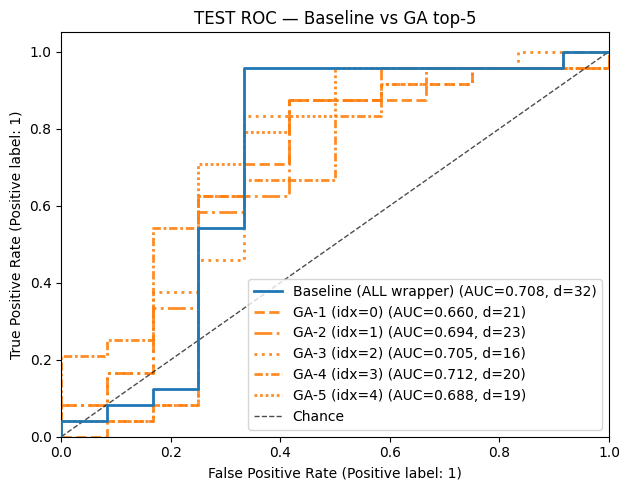


===== SUMMARY: Baseline + GA top-5 (CV & TEST) =====
                     name  n_features  cv_auc_best  cv_auc_mean  cv_auc_std  \
0  Baseline (ALL wrapper)          32     0.873333     0.873333    0.088377   
1            GA-1 (idx=0)          21     0.906061     0.906061    0.033961   
2            GA-2 (idx=1)          23     0.870000     0.870000    0.090211   
3            GA-3 (idx=2)          16     0.874242     0.874242    0.063506   
4            GA-4 (idx=3)          20     0.864242     0.864242    0.098964   
5            GA-5 (idx=4)          19     0.848485     0.848485    0.102691   

   test_auc  
0  0.708333  
1  0.659722  
2  0.694444  
3  0.704861  
4  0.711806  
5  0.687500  


In [4]:
# Cell 3: Final train on FULL TRAIN + TEST ROC (Baseline + GA top-5)

plt.figure(figsize=(6.4, 5.0))

test_rows = []

# Colors: one for Baseline, one shared color for all GA subsets
COLOR_BASELINE = "tab:blue"   # unique color for Baseline
COLOR_GA       = "tab:orange" # shared color for all GA feature sets

# Different linestyles for GA-1 ... GA-5 (same color, different pattern)
GA_LINESTYLES = [
    "--",              # GA-1
    "-.",              # GA-2
    ":",               # GA-3
    (0, (3, 1, 1, 1)), # GA-4 (custom dash pattern)
    (0, (1, 1)),       # GA-5 (dense dash)
]

ga_idx = 0  # index to assign linestyles for GA subsets

for fs in feature_sets:
    cols   = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])

    Xtr_sub = X_train.iloc[:, cols].to_numpy()
    Xte_sub = X_test.iloc[:,  cols].to_numpy()

    clf = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params
    )
    clf.fit(Xtr_sub, y_np)
    prob_te = clf.predict_proba(Xte_sub)[:, 1]

    auc_te = roc_auc_score(y_te, prob_te)
    fpr, tpr, _ = roc_curve(y_te, prob_te)

    # Style for Baseline vs GA subsets
    if fs["name"].lower().startswith("baseline"):
        # Baseline: thick, solid, fully opaque, highest z-order
        curve_color = COLOR_BASELINE
        line_style  = "-"
        alpha       = 1.0
        z           = 3
    else:
        # GA subsets: same color, different linestyles, slightly thinner
        curve_color = COLOR_GA
        # Safeguard: if more GA sets than styles, wrap around
        line_style  = GA_LINESTYLES[min(ga_idx, len(GA_LINESTYLES) - 1)]
        alpha       = 0.9
        z           = 2
        ga_idx += 1

    label = f"{fs['name']} (AUC={auc_te:.3f}, d={len(cols)})"

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=label,
        color=curve_color,
        linestyle=line_style,
        alpha=alpha,
        zorder=z,
    )

    test_rows.append({
        "name": fs["name"],
        "n_features": int(len(cols)),
        "cv_auc_mean": float(fs.get("cv_auc_mean", np.nan)),
        "cv_auc_std":  float(fs.get("cv_auc_std",  np.nan)),
        "cv_auc_best": float(fs.get("cv_auc", np.nan)),  # from tuning
        "test_auc":    float(auc_te),
    })

# Chance line
plt.plot([0, 1], [0, 1], "--", lw=1, label="Chance", color="black", alpha=0.7)

plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("TEST ROC — Baseline vs GA top-5")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(test_rows)
print("\n===== SUMMARY: Baseline + GA top-5 (CV & TEST) =====")
print(results_df[["name", "n_features", "cv_auc_best", "cv_auc_mean", "cv_auc_std", "test_auc"]])


In [5]:
# Cell: attach CV AUC / sensitivity from tables, then choose GA subset for SHAP

# 0) GA-only feature sets (Baseline 제외)
ga_feature_sets = [fs for fs in feature_sets if fs["name"].startswith("GA-")]
if len(ga_feature_sets) == 0:
    raise ValueError("No GA feature sets found in feature_sets (expected names starting with 'GA-').")

# 1) Lookup tables from auc_table / sens_table
#    - auc_table columns: "subset", "cv_auc_mean_over_folds", "cv_auc_std_over_folds"
#    - sens_table columns: "subset", "sensitivity_mean_at_0.5", "sensitivity_std_at_0.5"
auc_lookup  = {row["subset"]: row for _, row in auc_table.iterrows()}
sens_lookup = {row["subset"]: row for _, row in sens_table.iterrows()}

# 2) Attach AUC / sensitivity stats into each GA feature set dict
for fs in ga_feature_sets:
    name = fs["name"]

    # ---- CV AUC mean / std ----
    if "cv_auc_mean" not in fs or "cv_auc_std" not in fs:
        auc_row = auc_lookup.get(name, None)
        if auc_row is not None:
            fs["cv_auc_mean"] = float(auc_row["cv_auc_mean_over_folds"])
            fs["cv_auc_std"]  = float(auc_row["cv_auc_std_over_folds"])
        else:
            fs["cv_auc_mean"] = float("nan")
            fs["cv_auc_std"]  = float("nan")

    # ---- Sensitivity mean / std at threshold 0.5 ----
    sens_row = sens_lookup.get(name, None)
    if sens_row is not None:
        fs["sensitivity_mean_at_0.5"] = float(sens_row["sensitivity_mean_at_0.5"])
        fs["sensitivity_std_at_0.5"]  = float(sens_row["sensitivity_std_at_0.5"])
    else:
        fs["sensitivity_mean_at_0.5"] = 0.0
        fs["sensitivity_std_at_0.5"]  = 0.0

# 3) Define composite score for SHAP target selection
#    shap_score = mean_AUC − λ_auc_std * std_AUC + λ_sens * sensitivity
LMB_AUC_STD = 1.5   # penalty weight for AUC variance
LMB_SENS    = 0.1   # reward weight for sensitivity

def shap_score(fs):
    """Composite score for selecting a GA subset for SHAP:
       shap_score = m_auc − LMB_AUC_STD * s_auc + LMB_SENS * sens
    """
    m_auc = fs.get("cv_auc_mean", float("nan"))
    s_auc = fs.get("cv_auc_std",  float("nan"))
    sens  = fs.get("sensitivity_mean_at_0.5", 0.0)
    return m_auc - LMB_AUC_STD * s_auc + LMB_SENS * sens

# 4) Print all GA candidates
print("[INFO] GA candidates:")
for fs in ga_feature_sets:
    name  = fs["name"]
    d     = len(fs["cols"])
    m_auc = fs.get("cv_auc_mean", float("nan"))
    s_auc = fs.get("cv_auc_std",  float("nan"))
    sens  = fs.get("sensitivity_mean_at_0.5", float("nan"))
    score = shap_score(fs)
    print(
        f"  {name}: d={d:2d}, "
        f"CV AUC={m_auc:.4f} ± {s_auc:.4f}, "
        f"sens@0.5={sens:.4f}, "
        f"shap_score={score:.4f}"
    )

# 5) Choose best GA subset for SHAP
best_ga = max(ga_feature_sets, key=shap_score)

print("\nChosen for SHAP (by shap_score = mean - λ_auc_std·std + λ_sens·sens):")
print(" name      :", best_ga["name"])
print(" mean AUC  :", best_ga["cv_auc_mean"])
print(" std AUC   :", best_ga["cv_auc_std"])
print(" sens@0.5  :", best_ga.get("sensitivity_mean_at_0.5", float('nan')))
print(" shap_score:", shap_score(best_ga))
print(" n_features:", len(best_ga["cols"]))


[INFO] GA candidates:
  GA-1 (idx=0): d=21, CV AUC=0.9061 ± 0.0340, sens@0.5=0.9073, shap_score=0.9458
  GA-2 (idx=1): d=23, CV AUC=0.8700 ± 0.0902, sens@0.5=0.9636, shap_score=0.8310
  GA-3 (idx=2): d=16, CV AUC=0.8742 ± 0.0635, sens@0.5=0.9636, shap_score=0.8753
  GA-4 (idx=3): d=20, CV AUC=0.8642 ± 0.0990, sens@0.5=1.0000, shap_score=0.8158
  GA-5 (idx=4): d=19, CV AUC=0.8485 ± 0.1027, sens@0.5=1.0000, shap_score=0.7944

Chosen for SHAP (by shap_score = mean - λ_auc_std·std + λ_sens·sens):
 name      : GA-1 (idx=0)
 mean AUC  : 0.906060606060606
 std AUC   : 0.03396103206332581
 sens@0.5  : 0.9072727272727275
 shap_score: 0.94584633069289
 n_features: 21


[INFO] Final GA-RF model for SHAP trained on full TRAIN.
[INFO] Xtr_ga shape: (82, 21)
[INFO] shap_exp.values shape: (82, 21, 2)
[INFO] shap_exp.data   shape: (82, 21)


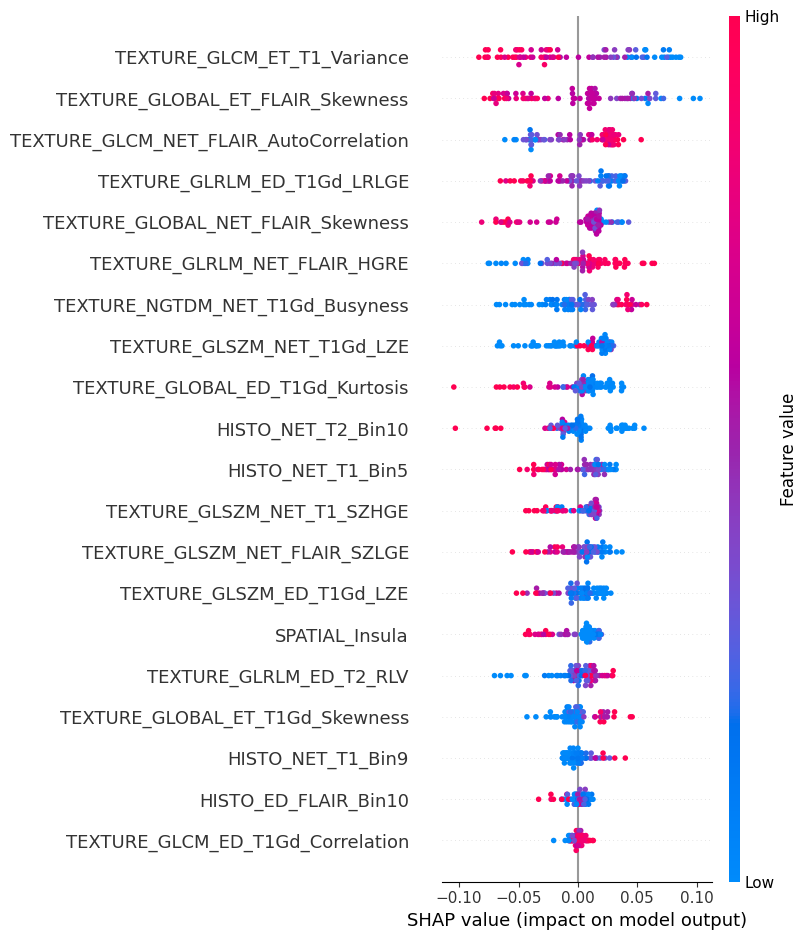

In [6]:
# Cell: Final GA-RF SHAP (clean version, no warnings)

RANDOM_STATE = 42

# 1) GA-selected feature subset from best_ga
ga_cols   = np.asarray(best_ga["cols"], dtype=int)
ga_params = dict(best_ga["best_params"])

Xtr_ga = X_train.iloc[:, ga_cols]
y_tr   = y_train.to_numpy().ravel()

# 2) Fit final RF on full TRAIN with the chosen GA subset
rf_ga_shap = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **ga_params
)
rf_ga_shap.fit(Xtr_ga, y_tr)

print("[INFO] Final GA-RF model for SHAP trained on full TRAIN.")
print("[INFO] Xtr_ga shape:", Xtr_ga.shape)

# 3) SHAP explainer (tree-based)
explainer = shap.Explainer(
    rf_ga_shap,
    Xtr_ga,            # background = train features
    algorithm="tree",
)

# 4) Compute SHAP values for TRAIN
shap_exp = explainer(Xtr_ga)

vals = shap_exp.values   # (n_samples, n_features, 2) in your case
data = shap_exp.data

print("[INFO] shap_exp.values shape:", vals.shape)
print("[INFO] shap_exp.data   shape:", data.shape)

# 5) For binary RF: pick positive class along the last axis
if vals.ndim == 3:
    # shape: (n_samples, n_features, n_outputs=2)
    vals = vals[:, :, 1]   # -> (n_samples, n_features)

# 6) Summary plot
shap.summary_plot(
    vals,
    data,
    feature_names=Xtr_ga.columns,
    show=True
)


In [7]:
# Cell: build t-SNE embedding on GA-selected feature subset (train + test)

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

# 1) Use GA-selected feature indices from best_ga (chosen by robust_score)
ga_cols = np.asarray(best_ga["cols"], dtype=int)

# 2) Subset train / test features using the same GA subset
Xtr_ga = X_train.iloc[:, ga_cols]
Xte_ga = X_test.iloc[:, ga_cols]

# 3) Stack train + test into a single matrix for a joint t-SNE embedding
X_all_ga = np.vstack([Xtr_ga.to_numpy(), Xte_ga.to_numpy()])

# y_np, y_te are already defined earlier as 1D numpy arrays
y_all = np.concatenate([y_np, y_te])

# Indicator for train vs test (for plotting)
split_label = np.array(
    ["train"] * len(y_np) + ["test"] * len(y_te)
)

print("[INFO] X_all_ga shape:", X_all_ga.shape)
print("[INFO] y_all length:", len(y_all))

# 4) Standardize features before running t-SNE
scaler = StandardScaler()
X_all_ga_scaled = scaler.fit_transform(X_all_ga)

# 5) Run t-SNE in 2D on GA-selected features
tsne = TSNE(
    n_components=2,
    perplexity=20,         # you can try 20–40 depending on how it looks
    learning_rate="auto",
    init="random",
    n_iter=1000,
    random_state=RANDOM_STATE,
    verbose=1,
)
X_all_tsne = tsne.fit_transform(X_all_ga_scaled)

print("[INFO] t-SNE embedding shape:", X_all_tsne.shape)

# 6) Pack into a DataFrame for convenient plotting
tsne_df = pd.DataFrame({
    "tsne1": X_all_tsne[:, 0],
    "tsne2": X_all_tsne[:, 1],
    "label": y_all,
    "split": split_label,
})


[INFO] X_all_ga shape: (118, 21)
[INFO] y_all length: 118
[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 118 samples in 0.000s...


c:\Users\junse\miniconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 118 samples in 0.317s...
[t-SNE] Computed conditional probabilities for sample 118 / 118
[t-SNE] Mean sigma: 1.830177
[t-SNE] KL divergence after 250 iterations with early exaggeration: 56.006748
[t-SNE] KL divergence after 1000 iterations: 0.698463
[INFO] t-SNE embedding shape: (118, 2)


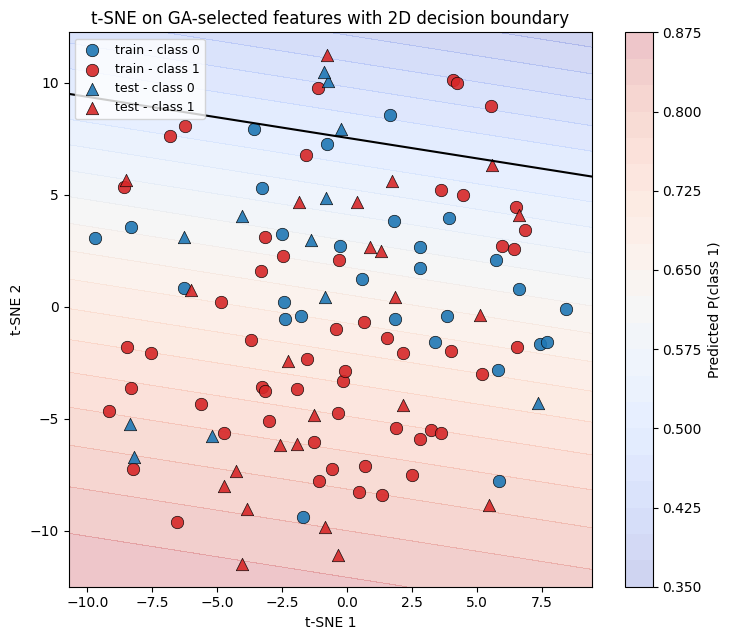

In [8]:
# Cell: t-SNE + decision boundary (color = class, marker = split)

from sklearn.linear_model import LogisticRegression

# -----------------------------
# 1) Train a simple classifier on t-SNE space
# -----------------------------
X_tsne = tsne_df[["tsne1", "tsne2"]].to_numpy()
y_tsne = tsne_df["label"].to_numpy()

clf_2d = LogisticRegression(random_state=42)
clf_2d.fit(X_tsne, y_tsne)

# -----------------------------
# 2) Make a grid over t-SNE space and get P(class=1)
# -----------------------------
x_min, x_max = tsne_df["tsne1"].min() - 1.0, tsne_df["tsne1"].max() + 1.0
y_min, y_max = tsne_df["tsne2"].min() - 1.0, tsne_df["tsne2"].max() + 1.0

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300),
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
proba_grid = clf_2d.predict_proba(grid_points)[:, 1]  # P(y=1)
proba_grid = proba_grid.reshape(xx.shape)

# -----------------------------
# 3) Plot decision surface + contour + points
# -----------------------------
plt.figure(figsize=(7.5, 6.5))

# (a) background: probability of class 1
cs = plt.contourf(
    xx, yy, proba_grid,
    levels=20,
    cmap="coolwarm",
    alpha=0.25,
)
cbar = plt.colorbar(cs)
cbar.set_label("Predicted P(class 1)")

# (b) decision boundary at P=0.5
plt.contour(
    xx, yy, proba_grid,
    levels=[0.5],
    colors="k",
    linewidths=1.5,
)

# (c) overlay the original points (color = class, marker = split)
colors = {0: "tab:blue", 1: "tab:red"}

for split, marker in [("train", "o"), ("test", "^")]:
    df_sub = tsne_df[tsne_df["split"] == split]
    for cls in sorted(df_sub["label"].unique()):
        mask = df_sub["label"] == cls
        if not np.any(mask):
            continue

        plt.scatter(
            df_sub.loc[mask, "tsne1"],
            df_sub.loc[mask, "tsne2"],
            s=80,
            alpha=0.9,
            marker=marker,
            color=colors.get(cls, "gray"),
            edgecolor="k",
            linewidths=0.5,
            label=f"{split} - class {cls}",
        )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE on GA-selected features with 2D decision boundary")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()
